# Station-MAE — Train vs. Test Data Exploration

A short companion to `Data_Exploration.ipynb`, focused on the **train / test split**
actually used by `main.py` (training) and `test.py` (evaluation).

**Contents**
1. Dataloader strategy — training vs. testing/evaluation
2. Dataset characteristics — train split vs. test split
3. Per-station variable panels — characteristics for one station, train vs. test

In [1]:
# ── Config & imports ─────────────────────────────────────────────────────────
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

# Reuse the project's own loader and split definitions so this notebook always
# matches what main.py / test.py actually do.
from data.dataset import (
    load_peakweather,
    VARIABLE_NAMES,          # ['temperature','pressure','humidity','wind_u','wind_v','precipitation']
    TRAIN_YEARS,             # 2017–2021
    VAL_YEARS,               # 2022
    TEST_YEARS,              # 2023–2024
)

# PeakWeather data root — first existing path wins (Renku, home, project folder)
_CANDIDATES = [
    "/home/renku/work/PeakWeatherDataset",
    os.path.expanduser("~/Documents/ETH/_DAS Project/PeakWeatherDataset"),
    os.path.expanduser("~/PeakWeatherDataset"),
    "PeakWeatherDataset",
]
DATA_ROOT = next((p for p in _CANDIDATES if os.path.isdir(p)), _CANDIDATES[-1])

UNITS = {"temperature":"°C","pressure":"hPa","humidity":"%",
         "wind_u":"m/s","wind_v":"m/s","precipitation":"mm"}

plt.rcParams.update({"figure.dpi":110, "font.size":10})
print("Data root  :", DATA_ROOT, "(found)" if os.path.isdir(DATA_ROOT) else "(missing – will download)")
print("Train years:", TRAIN_YEARS)
print("Val   years:", VAL_YEARS)
print("Test  years:", TEST_YEARS)

Data root  : /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset (found)
Train years: [2017, 2018, 2019, 2020, 2021]
Val   years: [2022]
Test  years: [2023, 2024]


## 1. Dataloader strategy — training vs. testing/evaluation

Both splits build the **same kind of sample**: a 12 h input window
`x` (W = 72 steps @ 10 min) over all stations, plus target snapshots at a grid of
lead-times `Δ` (0 h … 6 h every 30 min → K = 13 horizons; `Δ = 0` is reconstruction).
A random fraction of **whole stations** is hidden from the encoder (station-level
masking). What differs is *how windows are selected* and *how masking is applied*:

| | **Training** (`main.py`) | **Testing / evaluation** (`test.py`) |
|---|---|---|
| Years | 2017–2021 | 2023–2024 (val = 2022) |
| Window selection | `index_mode="random"` — sampled **with replacement** from all contiguity-valid starts; `__getitem__` ignores the DataLoader index | `index_mode="blocks"` — **non-overlapping** windows; test offset by W/4 (≈3 h) so blocks land at 03:00 / 15:00 |
| Epoch size | fixed `random_epoch_size` (e.g. 8 000 windows/epoch) | one pass over all blocks (~1 460 windows) |
| Shuffle | `shuffle=True` | `shuffle=False` (deterministic) |
| Masking | random mask each step, ratio 0.5 | mask-ratio **sweep** (0.0 = pure forecast, 0.5 = trained gap-fill), repeated `gap_fill_repeats` times |
| Normalisation stats | computed on the **train** split | **reuse train stats** (never recomputed on test) |

A window start `i` is valid only if the whole span `[i, i + W-1 + max_Δ]` has no
temporal gaps; per-station missing values are handled separately by the sensor mask.
Below we look at the raw data feeding these two splits.

In [2]:
# ── Load PeakWeather (meteo stations, wind → u/v, 6 variables) ────────────────
# The loader uses imputation_method=None, so gaps are NaN. We ALSO pull the
# explicit availability mask (1 = present, 0 = missing) and apply it, so every
# statistic below is computed on genuinely-observed values only — matching how
# build_observations() in dataset.py derives its mask ( ~isnan ).
ds = load_peakweather(root=DATA_ROOT)

try:
    obs, mask = ds.get_observations(parameters=VARIABLE_NAMES, return_mask=True)
    mask = mask.astype(bool)
    # Force any sensor flagged missing to NaN, even if it held a filled value.
    mask = mask.reindex(columns=obs.columns)
    obs = obs.where(mask)                       # missing sensors → NaN
    print(f"Mask loaded: {100*mask.values.mean():.1f}% of (step, station, var) present")
    _agree = (obs.notna().values == mask.values).mean()
    print(f"NaN vs mask agreement: {100*_agree:.2f}%  (should be ~100%)")
except TypeError:
    # Older API without return_mask — fall back to NaN as the missingness signal
    obs = ds.get_observations(parameters=VARIABLE_NAMES)
    print("return_mask not supported by this peakweather version — using NaN as mask "
          "(equivalent, since imputation_method=None).")

obs.index = pd.to_datetime(obs.index)

stations = obs.columns.get_level_values(0).unique().tolist()
print(f"Stations           : {len(stations)}")
print(f"Timesteps          : {len(obs):,}  ({obs.index[0].date()} → {obs.index[-1].date()})")
print(f"Variables          : {VARIABLE_NAMES}")

# Split the time axis by year, exactly like the dataset class does
year = obs.index.year
split_mask = {
    "train": np.isin(year, TRAIN_YEARS),
    "val":   np.isin(year, VAL_YEARS),
    "test":  np.isin(year, TEST_YEARS),
}

Stations           : 156
Timesteps          : 461,952  (2017-01-01 → 2025-10-13)
Variables          : ['temperature', 'pressure', 'humidity', 'wind_u', 'wind_v', 'precipitation']


In [3]:
# ── Dataset characteristics per split ────────────────────────────────────────
def split_summary(name, m):
    sub = obs.loc[m]
    n_steps = len(sub)
    present = sub.notna().values.mean() * 100      # % of (step,station,var) present
    # Non-overlapping 12h windows ≈ independent samples
    W = 72
    n_windows = n_steps // W
    return {
        "split": name,
        "years": {"train":TRAIN_YEARS,"val":VAL_YEARS,"test":TEST_YEARS}[name],
        "timesteps": n_steps,
        "date_start": sub.index[0].date() if n_steps else None,
        "date_end":   sub.index[-1].date() if n_steps else None,
        "coverage_%": round(present, 1),
        "~indep. 12h windows": n_windows,
    }

summary = pd.DataFrame([split_summary(s, m) for s, m in split_mask.items()]).set_index("split")
display(summary)

,years,timesteps,date_start,date_end,coverage_%,~indep. 12h windows
split,,,,,,
train,"[2017, 2018, 2019, 2020, 2021]",262944,2017-01-01,2021-12-31,93.0,3652
val,[2022],52560,2022-01-01,2022-12-31,93.4,730
test,"[2023, 2024]",105264,2023-01-01,2024-12-31,93.7,1462


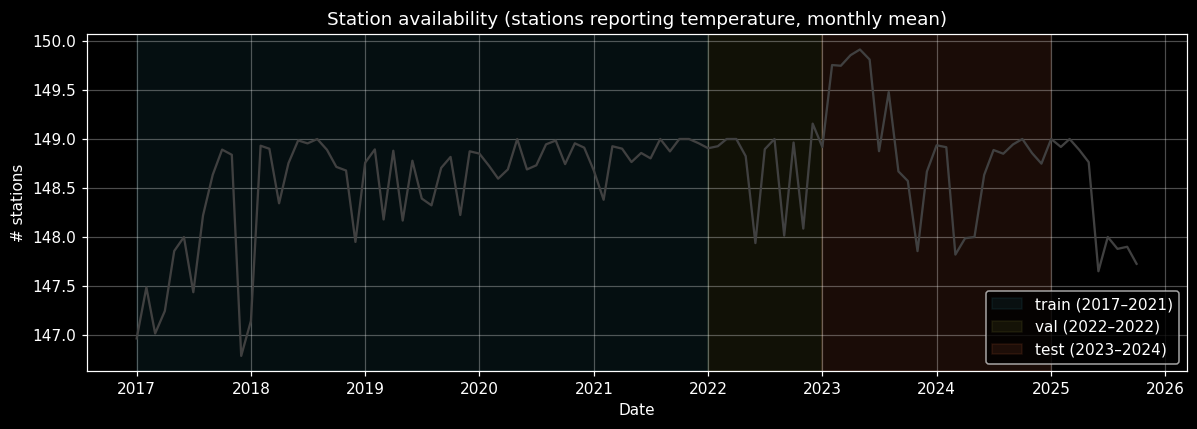

In [4]:
# ── Station availability over time, coloured by split ────────────────────────
# Number of stations reporting temperature, monthly mean.
temp_wide = obs.xs("temperature", axis=1, level=1)     # (datetime × stations)
avail = temp_wide.notna().sum(axis=1)
avail_m = avail.resample("MS").mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(avail_m.index, avail_m.values, color="0.25", lw=1.5)

colors = {"train":"#2E7D8C", "val":"#8E8E38", "test":"#D9663D"}
for name, m in split_mask.items():
    if m.any():
        idx = obs.index[m]
        ax.axvspan(idx.min(), idx.max(), color=colors[name], alpha=0.12,
                   label=f"{name} ({idx.min().year}–{idx.max().year})")

ax.set_title("Station availability (stations reporting temperature, monthly mean)")
ax.set_ylabel("# stations"); ax.set_xlabel("Date")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
# ── Per-variable statistics: train vs test ───────────────────────────────────
def var_stats(m):
    sub = obs.loc[m]
    rows = {}
    for v in VARIABLE_NAMES:
        col = sub.xs(v, axis=1, level=1).values.ravel()
        col = col[~np.isnan(col)]
        rows[v] = {
            "mean": np.mean(col), "std": np.std(col),
            "min": np.min(col), "max": np.max(col),
            "missing_%": 100 * (1 - col.size / sub.xs(v, axis=1, level=1).size),
        }
    return pd.DataFrame(rows).T

stats_train = var_stats(split_mask["train"])
stats_test  = var_stats(split_mask["test"])

compare = pd.concat({"TRAIN (2017–21)": stats_train,
                     "TEST (2023–24)":  stats_test}, axis=1)
display(compare.style.format("{:.2f}")
        .set_caption("Per-variable distribution — train vs test (all stations pooled)"))

## 2. Per-station variable panels

Pick one station and compare its variable characteristics between the training
period (2017–2021) and the test period (2023–2024). This surfaces distribution
shift (e.g. a warmer test period, sensor changes) that the model must handle at
evaluation time.

In [18]:
# ── Choose a station ─────────────────────────────────────────────────────────
STATION = "GES"  # ← change to any station id
print("Selected station:", STATION)

sdf = obs.xs(STATION, axis=1, level=0).copy()   # columns = variables, index = datetime
sdf = sdf.reindex(columns=VARIABLE_NAMES)
s_train = sdf.loc[split_mask["train"]]
s_test  = sdf.loc[split_mask["test"]]
print(f"  train rows: {len(s_train):,}   test rows: {len(s_test):,}")

Selected station: GES
  train rows: 262,944   test rows: 105,264


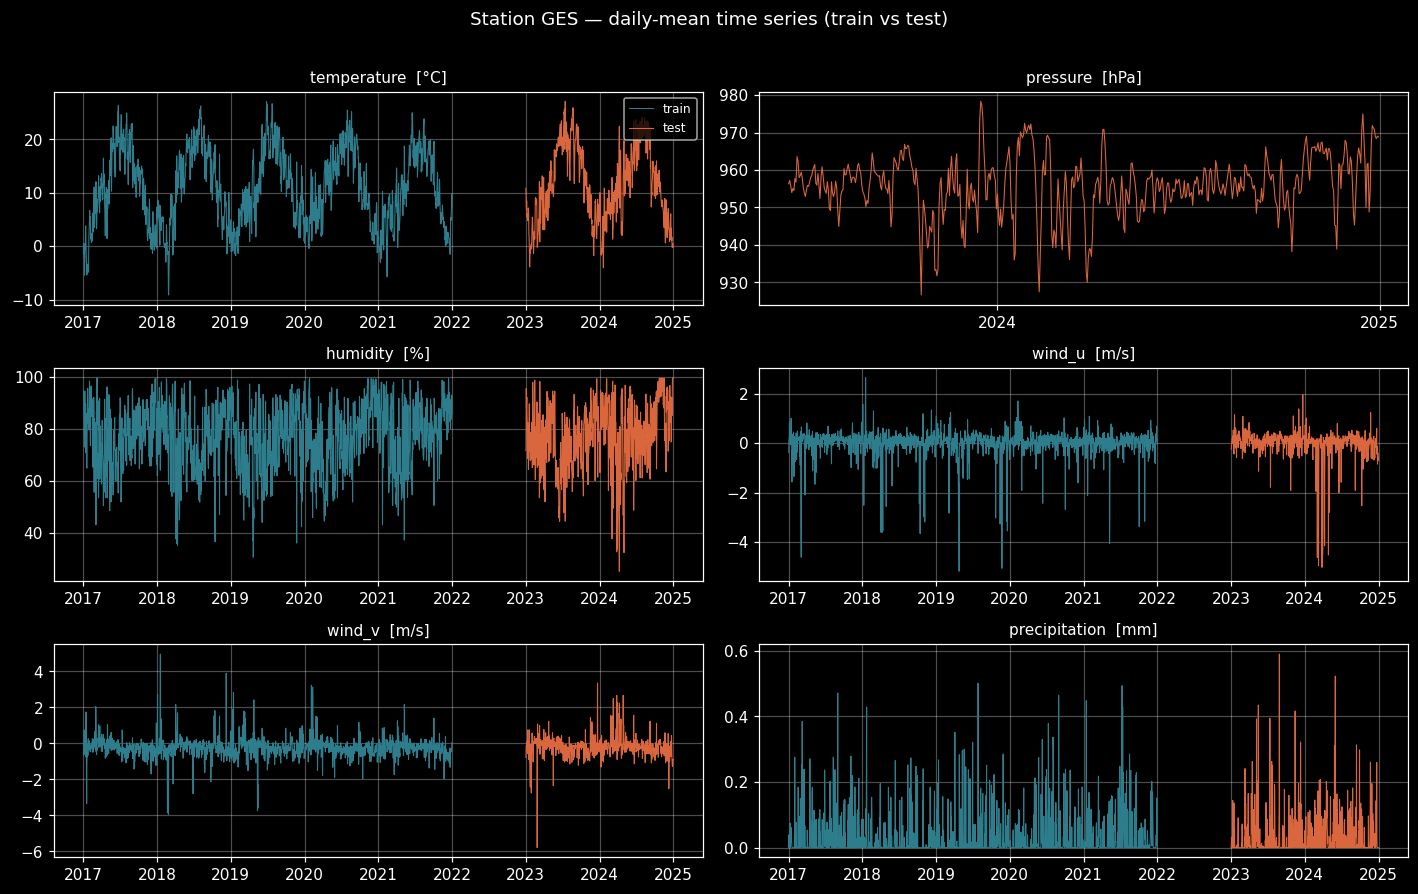

In [24]:
# ── Window 1: time-series panel (daily mean per variable) ────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharex=False)
for ax, v in zip(axes.ravel(), VARIABLE_NAMES):
    for label, part, c in [("train", s_train, "#2E7D8C"), ("test", s_test, "#D9663D")]:
        daily = part[v].resample("D").mean()
        ax.plot(daily.index, daily.values, color=c, lw=0.7, label=label)
    ax.set_title(f"{v}  [{UNITS[v]}]", fontsize=10)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes.ravel()[0].legend(loc="upper right", fontsize=8)
fig.suptitle(f"Station {STATION} — daily-mean time series (train vs test)", y=1.01)
plt.tight_layout(); plt.show()

/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


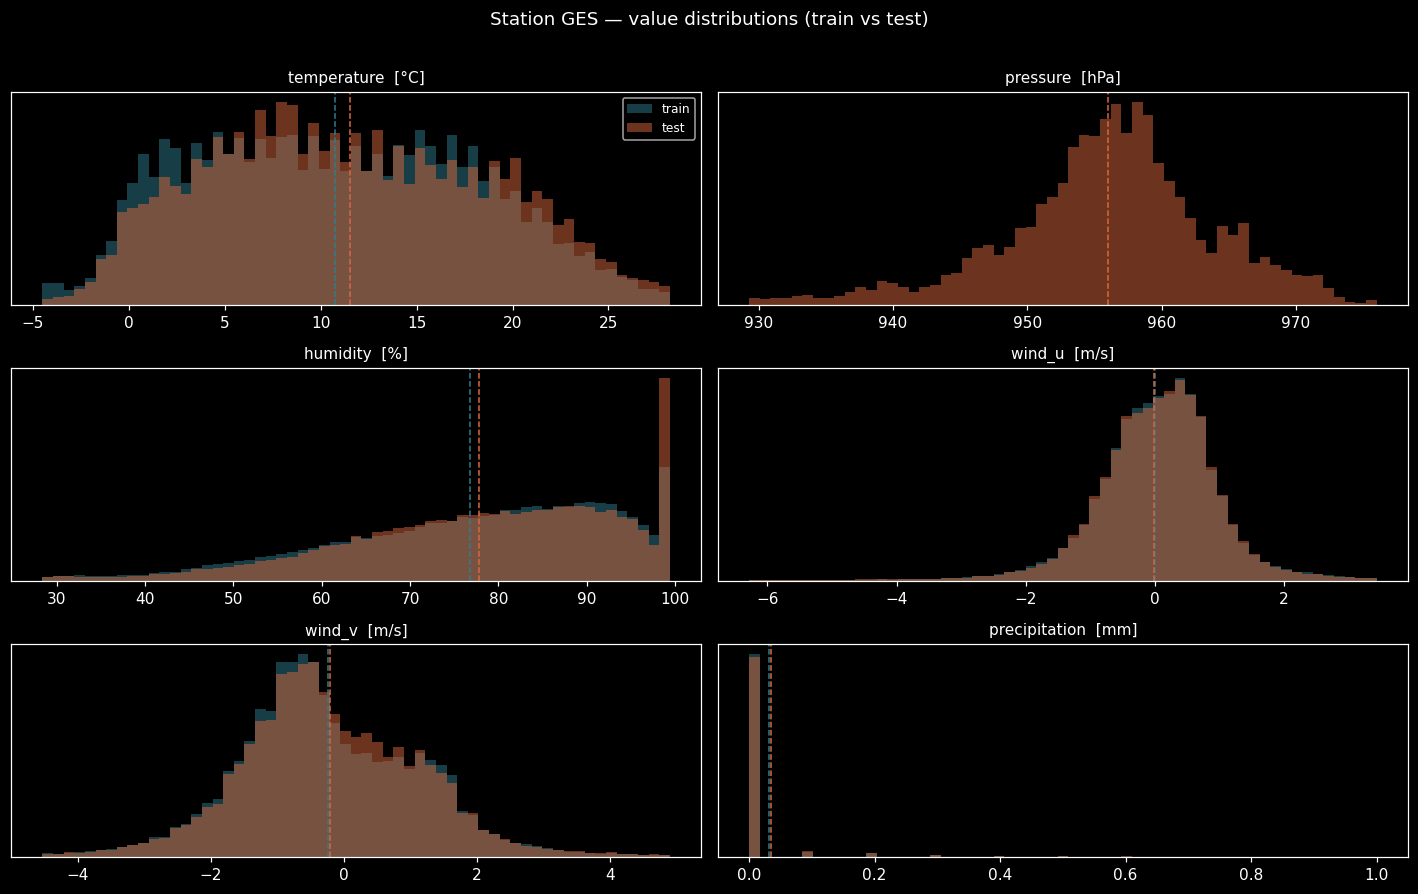

In [25]:
# ── Window 2: distribution panel (histograms per variable) ───────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 8))
for ax, v in zip(axes.ravel(), VARIABLE_NAMES):
    a = s_train[v].dropna().values
    b = s_test[v].dropna().values
    lo = np.nanpercentile(np.concatenate([a, b]), 0.5)
    hi = np.nanpercentile(np.concatenate([a, b]), 99.5)
    bins = np.linspace(lo, hi, 60)
    ax.hist(a, bins=bins, density=True, alpha=0.5, color="#2E7D8C", label="train")
    ax.hist(b, bins=bins, density=True, alpha=0.5, color="#D9663D", label="test")
    ax.axvline(np.mean(a), color="#2E7D8C", ls="--", lw=1)
    ax.axvline(np.mean(b), color="#D9663D", ls="--", lw=1)
    ax.set_title(f"{v}  [{UNITS[v]}]", fontsize=10)
    ax.set_yticks([])
axes.ravel()[0].legend(fontsize=8)
fig.suptitle(f"Station {STATION} — value distributions (train vs test)", y=1.01)
plt.tight_layout(); plt.show()

In [26]:
# ── Per-station numeric comparison (train vs test) ───────────────────────────
def per_station_stats(part):
    out = {}
    for v in VARIABLE_NAMES:
        col = part[v].dropna().values
        out[v] = {"mean": col.mean() if col.size else np.nan,
                  "std":  col.std()  if col.size else np.nan,
                  "missing_%": 100 * (1 - col.size / max(len(part), 1))}
    return pd.DataFrame(out).T

tbl = pd.concat({"TRAIN": per_station_stats(s_train),
                 "TEST":  per_station_stats(s_test)}, axis=1)
# Mean shift = test mean − train mean, in physical units
shift = (per_station_stats(s_test)["mean"] - per_station_stats(s_train)["mean"]).rename("Δmean (test−train)")
display(tbl.style.format("{:.2f}").set_caption(f"Station {STATION} — train vs test"))
display(shift.to_frame().style.format("{:+.2f}"))

,Δmean (test−train)
temperature,+0.75
pressure,+nan
humidity,+1.02
wind_u,-0.02
wind_v,+0.03
precipitation,+0.00


## 3. Variables >50% missing in training but present in testing

For each `(station, variable)` we compare availability in the **train** years vs the
**test** years. We flag pairs whose training series is **more than 50% missing**
(i.e. present in fewer than half of the available training timesteps) **and** that are
**observed at test time**. These are stations/variables the model barely saw during
training yet must handle at evaluation.

Reference: `dataset.py` also falls back to global normalisation stats when a pair has
fewer than `MIN_OBS = 50` training observations — reported alongside for context.

In [27]:
# ── Stations/variables >50% missing in train but present in test ─────────────
MIN_OBS       = 50    # dataset.py global-norm fallback threshold (for context)
MISS_THRESH   = 50.0  # % of training timesteps that must be missing to flag

n_train = int(split_mask["train"].sum())   # available training timesteps
n_test  = int(split_mask["test"].sum())    # available test timesteps

cnt_train = obs.loc[split_mask["train"]].notna().sum()   # Series: MultiIndex (station, variable)
cnt_test  = obs.loc[split_mask["test"]].notna().sum()

counts = pd.DataFrame({"train_count": cnt_train, "test_count": cnt_test})
counts.index = counts.index.set_names(["station", "variable"])
counts["train_missing_%"] = 100 * (1 - counts["train_count"] / n_train)
counts["test_present_%"]  = 100 * (counts["test_count"] / n_test)

# >50% missing in training AND present in testing
flagged = counts[(counts["train_missing_%"] > MISS_THRESH) & (counts["test_count"] > 0)]
flagged = flagged.reset_index()

print(f"Train timesteps: {n_train:,}   Test timesteps: {n_test:,}")
print(f"Pairs >{MISS_THRESH:.0f}% missing in train but present in test: "
      f"{len(flagged)} (station, variable)\n")

# Per-station rollup: which variables are affected at each station
if len(flagged):
    rollup = (flagged.groupby("station")["variable"]
                     .apply(lambda s: ", ".join(sorted(s)))
                     .rename("variables_>50%_missing_in_train")
                     .reset_index())
    rollup["n_variables"] = rollup["variables_>50%_missing_in_train"].str.count(",") + 1
    display(rollup.sort_values("n_variables", ascending=False).reset_index(drop=True))

    # Full detail with percentages
    detail = (flagged.sort_values(["train_missing_%", "station"], ascending=[False, True])
                     [["station", "variable", "train_count", "train_missing_%",
                       "test_count", "test_present_%"]]
                     .round(1).reset_index(drop=True))
    display(detail)
    out_csv = "train_missing50_test_present.csv"
    detail.to_csv(out_csv, index=False)
    print(f"\nSaved detailed list → {out_csv}")
else:
    print("None — no (station, variable) is >50% missing in training while present in test.")

Train timesteps: 262,944   Test timesteps: 105,264
Pairs >50% missing in train but present in test: 9 (station, variable)



,station,variables_>50%_missing_in_train,n_variables
0,PFA,"humidity, precipitation, pressure, temperature...",6
1,LAE,"wind_u, wind_v",2
2,GES,pressure,1


,station,variable,train_count,train_missing_%,test_count,test_present_%
0,GES,pressure,0,100.0,81434,77.4
1,LAE,wind_u,0,100.0,105169,99.9
2,LAE,wind_v,0,100.0,105169,99.9
3,PFA,temperature,0,100.0,105086,99.8
4,PFA,pressure,0,100.0,105264,100.0
5,PFA,humidity,0,100.0,105264,100.0
6,PFA,wind_u,0,100.0,105264,100.0
7,PFA,wind_v,0,100.0,105264,100.0
8,PFA,precipitation,0,100.0,105264,100.0



Saved detailed list → train_missing50_test_present.csv


In [28]:
cnt_train.head()

nat_abbr  name       
ABO       temperature    262944
AEG       temperature         0
AIG       temperature    262944
ALT       temperature    262944
AND       temperature    262944
dtype: int64

In [29]:
counts.head()

,,train_count,test_count,train_missing_%,test_present_%
station,variable,,,,
ABO,temperature,262944,105099,0.0,99.843251
AEG,temperature,0,0,100.0,0.000000
AIG,temperature,262944,105264,0.0,100.000000
ALT,temperature,262944,105264,0.0,100.000000
AND,temperature,262944,105264,0.0,100.000000
